In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Fake input and target
x = torch.tensor([[1.0, 2.0]], requires_grad=True)
y = torch.tensor([[0.0]])  # target

# Define weights manually
W1 = torch.tensor([[0.1, 0.2], [0.3, 0.4]], requires_grad=True)
b1 = torch.tensor([0.0, 0.0], requires_grad=True)

W2 = torch.tensor([[0.5], [0.6]], requires_grad=True)
b2 = torch.tensor([0.0], requires_grad=True)

# Forward pass
z1 = x @ W1 + b1      # Linear
a1 = torch.sigmoid(z1)  # Activation
z2 = a1 @ W2 + b2     # Output
y_hat = torch.sigmoid(z2)  # Sigmoid for binary output

# Loss
loss = F.mse_loss(y_hat, y)

# Backward
loss.backward()

# Print gradients
print("Grad W2:", W2.grad)
print("Grad W1:", W1.grad)


Grad W2: tensor([[0.1976],
        [0.2162]])
Grad W1: tensor([[0.0328, 0.0349],
        [0.0656, 0.0698]])


In [ ]:
| Gradient  | Meaning                           | Computation depth     |
| --------- | --------------------------------- | --------------------- |
| `W2.grad` | How much to change output weights | Shallow (direct)      |
| `W1.grad` | How much to change hidden weights | Deep (via chain rule) |


In [ ]:
W2.grad: This is the gradient of the loss with respect to the weights in the output layer.
    “If I change this weight in the output layer a little, how much will the loss change?”

W1.grad: This is the gradient with respect to the weights in the hidden layer.
    How much should I change this hidden-layer weight to reduce the loss?”

-----------------------------------------------> '' W = W - lr * W.grad ''<---------------------------------------------------


C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\3202231305.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\3202231305.py:61: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("forward_pass.png")


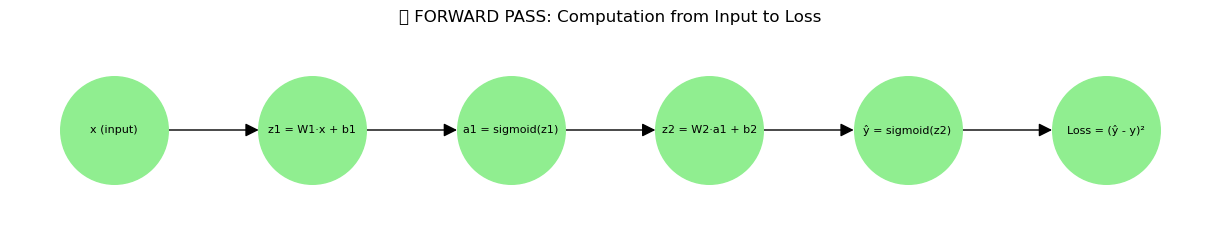

C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\3202231305.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\3202231305.py:89: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("backward_pass.png")


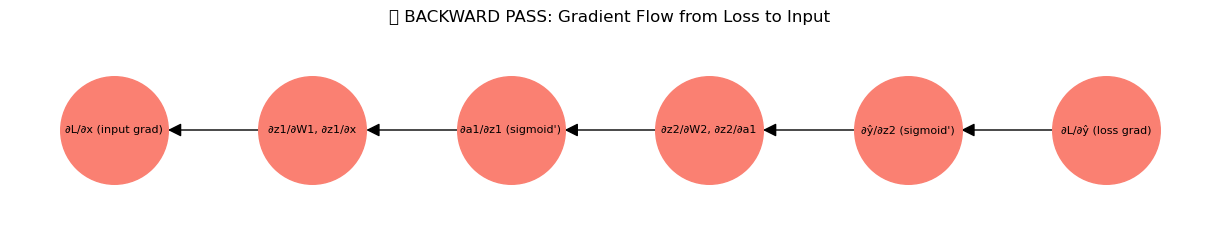

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx

# ----- STEP 1: Define input, weights, target -----
x = torch.tensor([[1.0, 2.0]], requires_grad=True)
y = torch.tensor([[0.0]])

W1 = torch.tensor([[0.1, 0.2], [0.3, 0.4]], requires_grad=True)
b1 = torch.tensor([0.0, 0.0], requires_grad=True)

W2 = torch.tensor([[0.5], [0.6]], requires_grad=True)
b2 = torch.tensor([0.0], requires_grad=True)

# ----- STEP 2: Forward pass -----
z1 = x @ W1 + b1
a1 = torch.sigmoid(z1)
z2 = a1 @ W2 + b2
y_hat = torch.sigmoid(z2)
loss = F.mse_loss(y_hat, y)

# ----- STEP 3: Backward pass -----
loss.backward()

# ----- STEP 4: Layout for both plots -----
pos = {
    "x": (0, 0),
    "z1": (1, 0),
    "a1": (2, 0),
    "z2": (3, 0),
    "y_hat": (4, 0),
    "L": (5, 0),
}

# ----- STEP 5: FORWARD PASS DIAGRAM -----
G_forward = nx.DiGraph()
G_forward.add_edges_from([
    ("x", "z1"),
    ("z1", "a1"),
    ("a1", "z2"),
    ("z2", "y_hat"),
    ("y_hat", "L"),
])

forward_labels = {
    "x": "x (input)",
    "z1": "z1 = W1·x + b1",
    "a1": "a1 = sigmoid(z1)",
    "z2": "z2 = W2·a1 + b2",
    "y_hat": "ŷ = sigmoid(z2)",
    "L": "Loss = (ŷ - y)²",
}

plt.figure(figsize=(12, 2))
nx.draw(G_forward, pos, with_labels=True, labels=forward_labels,
        node_color='lightgreen', node_size=6000, arrowsize=20, font_size=8)
plt.title("🔵 FORWARD PASS: Computation from Input to Loss")
plt.axis("off")
plt.tight_layout()
plt.savefig("forward_pass.png")
plt.show()

# ----- STEP 6: BACKWARD PASS DIAGRAM -----
G_backward = nx.DiGraph()
G_backward.add_edges_from([
    ("L", "y_hat"),
    ("y_hat", "z2"),
    ("z2", "a1"),
    ("a1", "z1"),
    ("z1", "x"),
])

backward_labels = {
    "L": "∂L/∂ŷ (loss grad)",
    "y_hat": "∂ŷ/∂z2 (sigmoid')",
    "z2": "∂z2/∂W2, ∂z2/∂a1",
    "a1": "∂a1/∂z1 (sigmoid')",
    "z1": "∂z1/∂W1, ∂z1/∂x",
    "x": "∂L/∂x (input grad)",
}

plt.figure(figsize=(12, 2))
nx.draw(G_backward, pos, with_labels=True, labels=backward_labels,
        node_color='salmon', node_size=6000, arrowsize=20, font_size=8)
plt.title("🔴 BACKWARD PASS: Gradient Flow from Loss to Input")
plt.axis("off")
plt.tight_layout()
plt.savefig("backward_pass.png")
plt.show()



In [ ]:
# for visualizing the backpropagation
import torch
import torch.nn.functional as F

# Input & Target
x = torch.tensor([[1.0, 2.0]], requires_grad=True)
y = torch.tensor([[0.0]])

# Weights and biases
W1 = torch.tensor([[0.1, 0.2],
                   [0.3, 0.4]], requires_grad=True)
b1 = torch.tensor([0.0, 0.0], requires_grad=True)

W2 = torch.tensor([[0.5],
                   [0.6]], requires_grad=True)
b2 = torch.tensor([0.0], requires_grad=True)

# Forward pass
z1 = x @ W1 + b1
a1 = torch.sigmoid(z1)
z2 = a1 @ W2 + b2
y_hat = torch.sigmoid(z2)
loss = F.mse_loss(y_hat, y)

# Backward pass
loss.backward()

# Print intermediate values and gradients
print("----- Forward Values -----")
print("x:\n", x)
print("z1:\n", z1)
print("a1 (after sigmoid):\n", a1)
print("z2:\n", z2)
print("ŷ (sigmoid):\n", y_hat)
print("Loss:\n", loss.item())

print("\n----- Gradients -----")
print("∂L/∂W2:\n", W2.grad)
print("∂L/∂b2:\n", b2.grad)
print("∂L/∂W1:\n", W1.grad)
print("∂L/∂b1:\n", b1.grad)
print("∂L/∂x:\n", x.grad)  # Optional: backprop through input


----- Forward Values -----
x:
 tensor([[1., 2.]], requires_grad=True)
z1:
 tensor([[0.7000, 1.0000]], grad_fn=<AddBackward0>)
a1 (after sigmoid):
 tensor([[0.6682, 0.7311]], grad_fn=<SigmoidBackward0>)
z2:
 tensor([[0.7727]], grad_fn=<AddBackward0>)
ŷ (sigmoid):
 tensor([[0.6841]], grad_fn=<SigmoidBackward0>)
Loss:
 0.46800777316093445

----- Gradients -----
∂L/∂W2:
 tensor([[0.1976],
        [0.2162]])
∂L/∂b2:
 tensor([0.2957])
∂L/∂W1:
 tensor([[0.0328, 0.0349],
        [0.0656, 0.0698]])
∂L/∂b1:
 tensor([0.0328, 0.0349])
∂L/∂x:
 tensor([[0.0103, 0.0238]])


In [ ]:
| Quantity             | Meaning                              |
| -------------------- | ------------------------------------ |
| `W1.grad`            | ∂L/∂W1 — how loss changes w\.r.t. W1 |
| `W2.grad`            | ∂L/∂W2 — how loss changes w\.r.t. W2 |
| `b1.grad`, `b2.grad` | ∂L/∂b1, ∂L/∂b2 respectively          |
| `x.grad` (optional)  | ∂L/∂x — how input affects the loss   |


In [ ]:
| Gradient  | Meaning                           | Computation depth     |
| --------- | --------------------------------- | --------------------- |
| `W2.grad` | How much to change output weights | Shallow (direct)      |
| `W1.grad` | How much to change hidden weights | Deep (via chain rule) |


------------------------------------------>W = W - lr * W.grad<---------------------------------------------------------


In [ ]:
| Goal                                            | Examples                                                   |
| ------------------------------------------------| --------------------------------------------------------------- |
| **Gradients control weight updates**            | Show `W1`, `W2` before & after `.backward()` + optimizer        |
| **Why zero gradients stop learning**            | Freeze gradients or manually zero `W.grad`, no learning happens |
| **Why large gradients cause exploding updates** | Use large weights or no activation: observe blowup              |
| **Why small gradients cause vanishing updates** | Use sigmoid with deep layers: show almost no learning           |


# Gradients Drive Learning !

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Simple 1-hidden layer network
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 1)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = torch.sigmoid(z1)
        z2 = self.fc2(a1)
        y_hat = torch.sigmoid(z2)
        return y_hat

# Initialize
net = SimpleNet()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

# Input/output
x = torch.tensor([[1.0, 2.0]])
y = torch.tensor([[0.0]])

# Forward
y_hat = net(x)
loss = F.mse_loss(y_hat, y)

# Print before training
print("Before training:")
for name, param in net.named_parameters():
    print(f"{name}: {param.data.numpy()}")

# Backward
loss.backward()

# Show gradients
print("\nGradients after backward:")
for name, param in net.named_parameters():
    print(f"{name}.grad:\n{param.grad.numpy()}")

# Optimizer step
optimizer.step()

# Print after weight update
print("\nAfter optimizer.step():")
for name, param in net.named_parameters():
    print(f"{name}: {param.data.numpy()}")


Before training:
fc1.weight: [[-0.3051908   0.40918595]
 [ 0.4267146  -0.13359708]]
fc1.bias: [-0.16284317  0.2883587 ]
fc2.weight: [[ 0.27101183 -0.2254622 ]]
fc2.bias: [0.51322085]

Gradients after backward:
fc1.weight.grad:
[[ 0.01930628  0.03861256]
 [-0.01575588 -0.03151176]]
fc1.bias.grad:
[ 0.01930628 -0.01575588]
fc2.weight.grad:
[[0.17236315 0.17924806]]
fc2.bias.grad:
[0.29378435]

After optimizer.step():
fc1.weight: [[-0.30712143  0.4053247 ]
 [ 0.4282902  -0.1304459 ]]
fc1.bias: [-0.16477379  0.28993428]
fc2.weight: [[ 0.2537755 -0.243387 ]]
fc2.bias: [0.4838424]


In [ ]:
“Each weight decides how to move based on its gradient.

If W.grad = 0, that means the loss doesn't care about this weight — and it won’t update.
If it's large, the weight will change drastically.

That’s why vanishing or exploding gradients break learning.”

Training: relu
Training: sigmoid_deep


C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\3628388171.py:81: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\3628388171.py:81: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


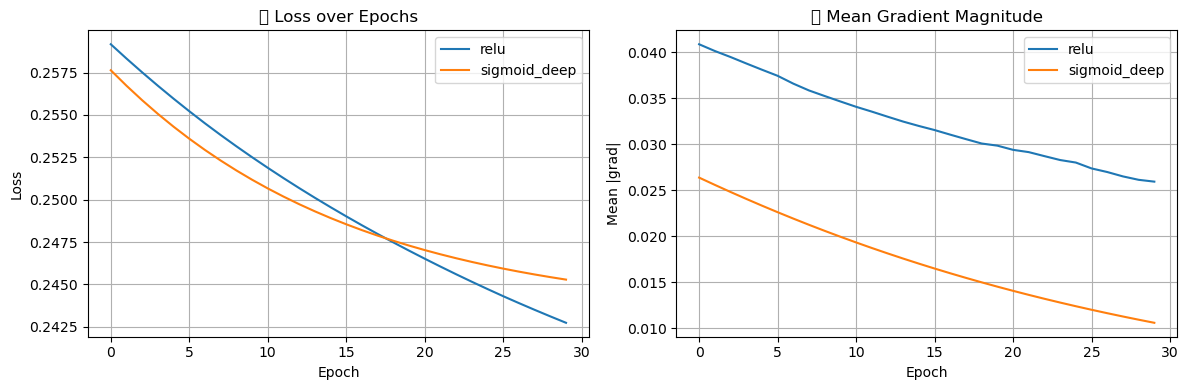

In [ ]:
# plot to show Gradient vs loss
#When i am saying loss gets reduced, this is what i meant.

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Data
X = torch.randn(100, 2)
y = (X[:, 0] * X[:, 1] > 0).float().unsqueeze(1)

# Model variants
def get_model(mode):
    if mode == 'relu':
        return nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    elif mode == 'sigmoid_deep':
        return nn.Sequential(
            nn.Linear(2, 8), nn.Sigmoid(),
            nn.Linear(8, 8), nn.Sigmoid(),
            nn.Linear(8, 1), nn.Sigmoid()
        )

# Train and log gradients
def train_with_grad_logging(model, epochs=30, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_log = []
    grad_log = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = F.mse_loss(y_pred, y)
        loss_log.append(loss.item())

        optimizer.zero_grad()
        loss.backward()

        # Mean of gradient magnitudes
        total_grad = 0
        count = 0
        for p in model.parameters():
            if p.grad is not None:
                total_grad += p.grad.norm().item()
                count += 1
        mean_grad = total_grad / count if count > 0 else 0
        grad_log.append(mean_grad)

        optimizer.step()

    return loss_log, grad_log

# Train both models
results = {}
for mode in ['relu', 'sigmoid_deep']:
    print(f"Training: {mode}")
    model = get_model(mode)
    loss_hist, grad_hist = train_with_grad_logging(model)
    results[mode] = (loss_hist, grad_hist)

# Plot Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for mode in results:
    plt.plot(results[mode][0], label=mode)
plt.title("📉 Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Plot Gradients
plt.subplot(1, 2, 2)
for mode in results:
    plt.plot(results[mode][1], label=mode)
plt.title("📈 Mean Gradient Magnitude")
plt.xlabel("Epoch")
plt.ylabel("Mean |grad|")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Vanishing Gradient

Training: normal_relu
Training: deep_sigmoid
Training: no_activation
Training: zero_grad


/tmp/ipykernel_1563658/3235367213.py:68: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


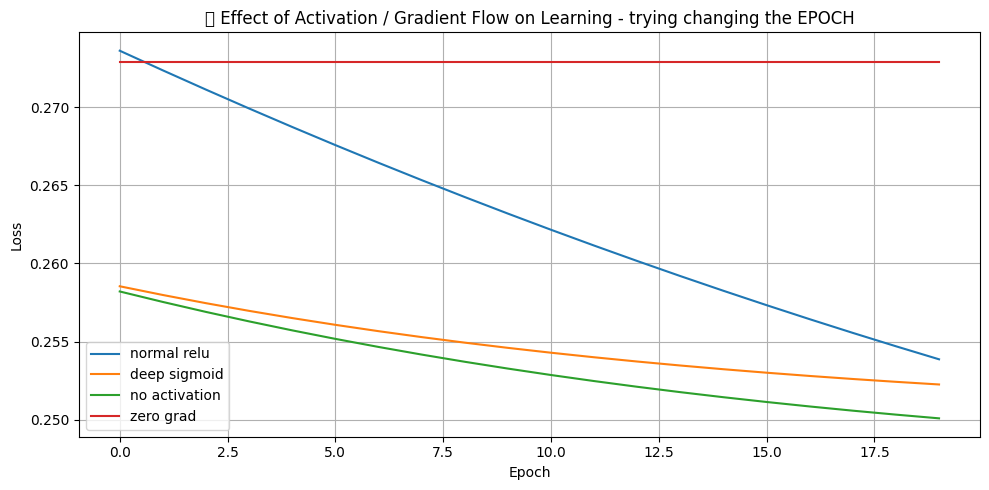

In [ ]:
# Visualization of loss vs epoch


import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Simple toy dataset
X = torch.randn(100, 2)
y = (X[:, 0] * X[:, 1] > 0).float().unsqueeze(1)  # XOR-like logic

# Define 4 network variants
def get_model(mode):
    layers = []
    if mode == 'normal_relu':
        layers = [nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid()]
    elif mode == 'deep_sigmoid':
        layers = [nn.Linear(2, 8), nn.Sigmoid(),
                  nn.Linear(8, 8), nn.Sigmoid(),
                  nn.Linear(8, 8), nn.Sigmoid(),
                  nn.Linear(8, 1), nn.Sigmoid()]
    elif mode == 'no_activation':
        layers = [nn.Linear(2, 8),  # No activation
                  nn.Linear(8, 1), nn.Sigmoid()]
    elif mode == 'zero_grad':
        layers = [nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid()]
    return nn.Sequential(*layers)

# Training loop
def train(model, mode, epochs=20, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_hist = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = F.mse_loss(y_pred, y)
        loss_hist.append(loss.item())

        optimizer.zero_grad()
        loss.backward()

        # Special case: block gradients
        if mode == 'zero_grad':
            for p in model.parameters():
                p.grad = torch.zeros_like(p.grad)

        optimizer.step()

    return loss_hist

# Run all modes
modes = ['normal_relu', 'deep_sigmoid', 'no_activation', 'zero_grad']
histories = {}
for mode in modes:
    print(f"Training: {mode}")
    model = get_model(mode)
    histories[mode] = train(model, mode)

# Plotting results
plt.figure(figsize=(10, 5))
for mode, loss_list in histories.items():
    plt.plot(loss_list, label=mode.replace('_', ' '))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("📉 Effect of Activation / Gradient Flow on Learning - trying changing the EPOCH")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
| Curve              | Behavior Expected              |
| ------------------ | ------------------------------ |
| **Normal ReLU**    | Loss drops steadily            |
| **Deep Sigmoid**   | Flat loss, barely improves     |
| **No Activation**  | Sharp drops, possibly unstable |
| **Zero Gradients** | No change at all               |


In [ ]:
# Exploding Gradients

What Causes Exploding Gradients?

No activation (pure linear stack)
Large initial weights
Too many layers


Epoch 01 | Loss = 1.6335e+22 | Mean ∇ = inf
Epoch 02 | Loss = nan | Mean ∇ = nan
⚠️ Loss exploded. Stopping early.


C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\1839692202.py:90: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\1839692202.py:90: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


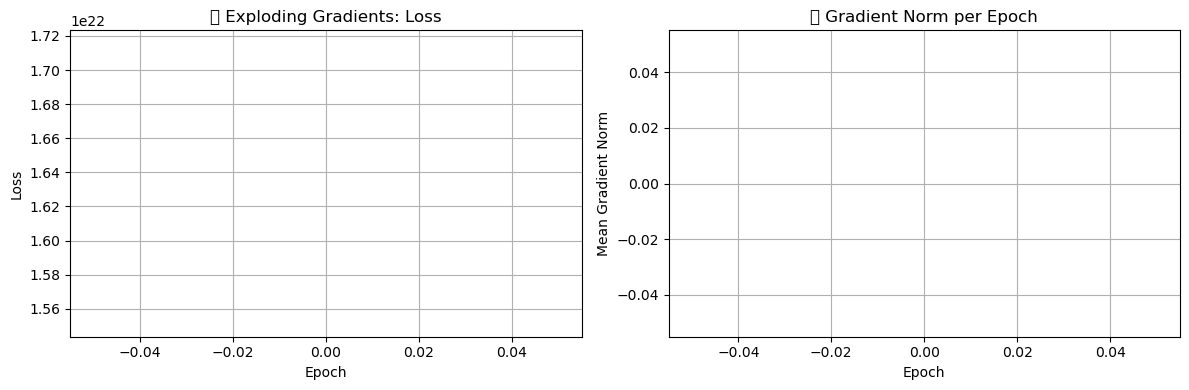

In [ ]:

#Exploding gradients


import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Fix: one sample input to isolate effects
X = torch.randn(1, 2)
y = torch.tensor([[1.0]])

# Define the exploding network
class ExplodingNet(nn.Module):
    def __init__(self, depth=6, scale=20.0):
        super().__init__()
        layers = []
        in_dim = 2
        for _ in range(depth):
            lin = nn.Linear(in_dim, 8)
            nn.init.normal_(lin.weight, std=scale)
            nn.init.zeros_(lin.bias)
            layers.append(lin)
            in_dim = 8
        out = nn.Linear(in_dim, 1)
        nn.init.normal_(out.weight, std=scale)
        nn.init.zeros_(out.bias)
        layers.append(out)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        for layer in self.net:
            x = layer(x)  # No activation
        return x  # No sigmoid

# Training loop
def train(model, epochs=20, lr=0.01):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_log = []
    grad_log = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = F.mse_loss(y_pred, y)
        loss_log.append(loss.item())

        optimizer.zero_grad()
        loss.backward()

        # Gradient magnitude tracking
        total_grad = 0.0
        param_count = 0
        for p in model.parameters():
            if p.grad is not None:
                total_grad += p.grad.norm().item()
                param_count += 1

        mean_grad = total_grad / param_count if param_count else 0
        grad_log.append(mean_grad)

        print(f"Epoch {epoch+1:02d} | Loss = {loss.item():.4e} | Mean ∇ = {mean_grad:.4e}")

        if not torch.isfinite(loss):
            print("⚠️ Loss exploded. Stopping early.")
            break

        optimizer.step()

    return loss_log, grad_log

# Build and run
model = ExplodingNet()
losses, grads = train(model)

# Only plot if there are values
if len(losses) > 1:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(losses, label="Loss")
    plt.title("💥 Exploding Gradients: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(grads, label="Mean ∇", color="red")
    plt.title("📈 Gradient Norm per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Gradient Norm")
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("🚫 No plot: Training did not progress far enough.")


In [ ]:
# Reasons for exploding gradients
Think about it, we are applying chain rule, we multiply !

Initial weights are large	-> Each layer’s output becomes large ⇒ gradients through chain rule get multiplied by large values
No activation functions	-> There’s nothing to "squash" or "normalize" outputs between layers ⇒ all gradients pass through unchecked
Deep network ->	The longer the chain rule (more layers), the more chances gradients blow up

In [ ]:
| Case                | Gradient        | Learning     | Output              |
| ------------------- | --------------- | ------------ | ------------------- |
| Vanishing Gradients | ≈ 0             | Slow / stuck | May still be active |
| Exploding Gradients | Huge            | Unstable     | Over-updates        |

In [ ]:
Solution - >   Good activations + Smart initialization + Normalization + (Optional) Gradient clipping

In [ ]:
What is an Activation Function?
An activation function is a non-linear function applied after each neuron’s linear operation:

z=W⋅x+b⇒a=ϕ(z)
Where:
z is the raw signal (weighted sum)
ϕ(z) is the activation (output of the neuron)


Without them, your network is just a linear function.

     Neural nets without activation = just a linear transformation
     Non-linearity is needed to model complex patterns (e.g., XOR)
     That’s why every hidden layer needs a non-linear function

In [ ]:
| Perspective          | Explanation                                                                                                                                     |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| Biological Neuron    | Like a neuron "firing" only if signal > threshold. No firing if the input is too weak.                                                          |
| Control System       | Like applying a **non-linear threshold** or **gain control** — it makes the system responsive only in certain regions.                          |
| Geometric            | Without activation functions, a neural network is just a big linear transformation. Activation introduces **curvature** to decision boundaries. |
| Learning             | Helps **backpropagation learn non-trivial patterns** by shaping the flow of gradients.                                                          |


In [ ]:
Why Do We Need Activation Functions?

A stack of only linear layers (no activation) collapses to a single matrix multiplication.

Example:

𝑧=𝑊3(𝑊2(𝑊1𝑥))=𝑊′𝑥

This means:
No matter how deep the network is, it behaves like a shallow linear model.

 ---------------> Activation functions inject non-linearity, which gives neural networks their universal approximation power.<----------------

In [ ]:
| Function       || Physical Meaning                          | Gradient Behavior                      |   |                  |
| -------------- || ----------------------------------------- | -------------------------------------- | - | ---------------- |
| **ReLU**       || Neuron fires only for positive input      | Gradient = 1 if $x > 0$, else 0        |   |                  |
| **Sigmoid**    || Soft threshold, like probability response | Gradient small for large (x)) ⇒ **vanishes*               |  |
| **Tanh**       || S-shaped curve from -1 to 1               | Still suffers vanishing                |   |                  |
| **Leaky ReLU** || Allows some gradient flow for   x < 0     | Fixes ReLU “dying” neurons             |   |                  |
| **Softmax**    || Converts scores to probabilities          | Used in final layer for classification |   |                  |


In [ ]:
# Crude way to remember!

Imagine a pipe system:

Linear layers: just push water forward
Activations: valves that let water flow only if pressure is high enough, or bend the flow direction
Without activations, the pipe system cannot control flow patterns — it's just a straight pipe

Training with ReLU...
Training with LeakyReLU...
Training with Tanh...
Training with Sigmoid...
Training with ELU...
Training with GELU...


C:\Users\fedex\AppData\Local\Temp\ipykernel_30556\824273746.py:95: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


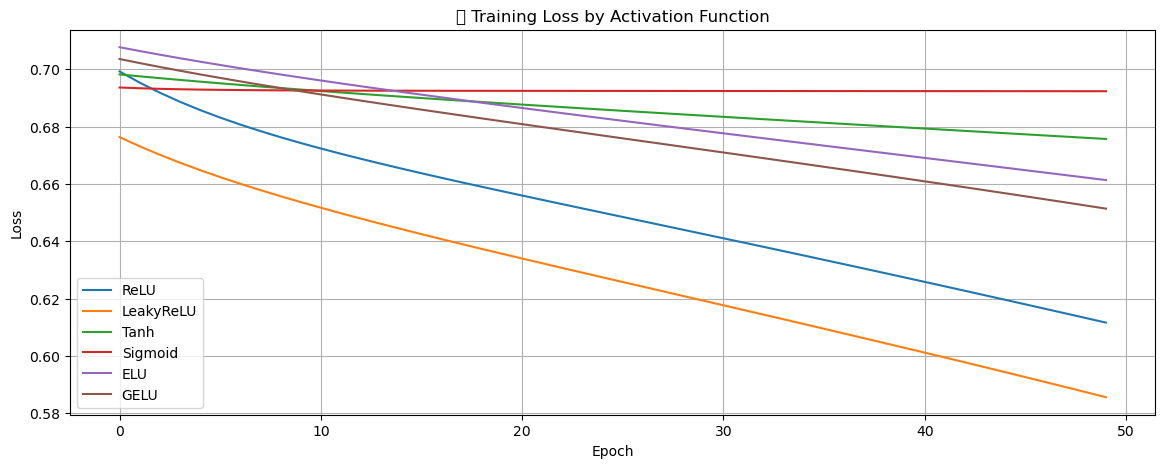

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


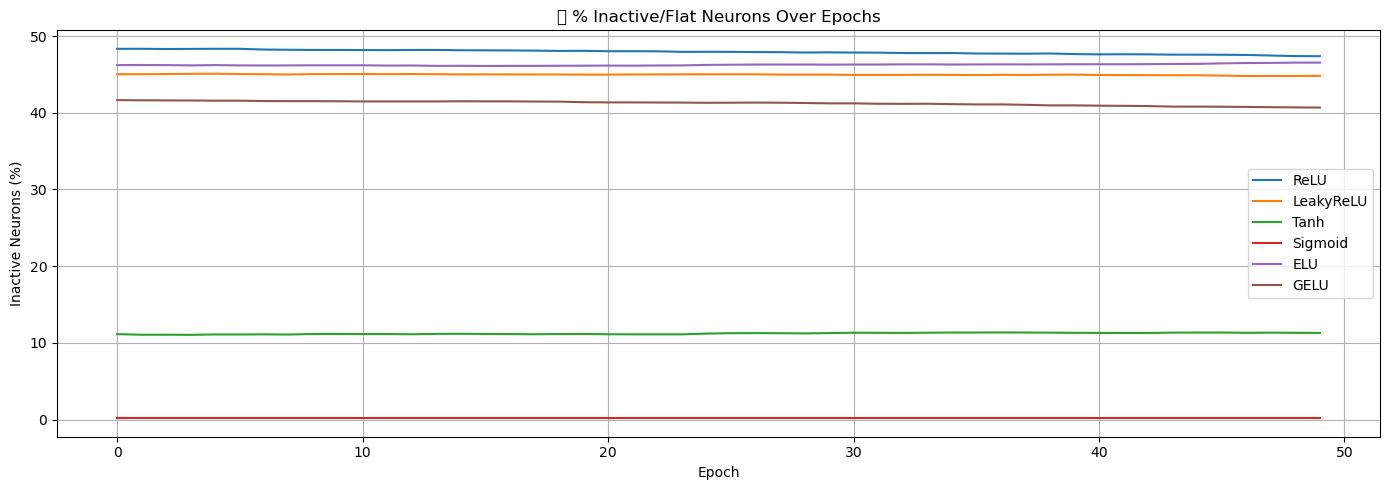

In [ ]:
# when we are saying no gradients update ,what does it physically mean?

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Synthetic XOR-like dataset
torch.manual_seed(42)
X = torch.randn(500, 2)
y = ((X[:, 0] * X[:, 1]) > 0).float().unsqueeze(1)

# Neural network with configurable activation
class SimpleNet(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 1)
        self.activation_fn = activation_fn

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.activation_fn(z1)
        self.last_hidden = a1  # for monitoring
        out = torch.sigmoid(self.fc2(a1))
        return out

# Training function with dead neuron tracking
def train_model(act_name, act_fn, epochs=50, lr=0.1):
    model = SimpleNet(act_fn)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_log = []
    dead_neurons = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = F.binary_cross_entropy(y_pred, y)
        loss_log.append(loss.item())

        # For ReLU-family, track dead neurons
        if act_name in ["ReLU", "LeakyReLU", "ELU", "GELU"]:
            inactive = (model.last_hidden <= 0).float().mean().item()
        elif act_name == "Sigmoid":
            inactive = (model.last_hidden < 0.1).float().mean().item()
        elif act_name == "Tanh":
            inactive = (torch.abs(model.last_hidden) < 0.1).float().mean().item()
        else:
            inactive = 0

        dead_neurons.append(inactive)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return loss_log, dead_neurons

# Activation functions to compare
activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.01),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "ELU": nn.ELU(),
    "GELU": nn.GELU()
}

# Run experiments
losses = {}
dead_logs = {}
for name, fn in activations.items():
    print(f"Training with {name}...")
    loss, dead = train_model(name, fn)
    losses[name] = loss
    dead_logs[name] = [d * 100 for d in dead]  # convert to %

# Plot Loss Comparison
plt.figure(figsize=(14, 5))
for name in activations:
    plt.plot(losses[name], label=name)
plt.title("📉 Training Loss by Activation Function")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot Dead Neuron Percentage
plt.figure(figsize=(14, 5))
for name in activations:
    plt.plot(dead_logs[name], label=name)
plt.title("🔻 % Inactive/Flat Neurons Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Inactive Neurons (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
| Name          | PyTorch Function     | Comments                        |
| ------------- | -------------------- | ------------------------------- |
| **ReLU**      | `nn.ReLU()`          | Risk of dying neurons           |
| **LeakyReLU** | `nn.LeakyReLU(0.01)` | Small negative slope            |
| **Tanh**      | `nn.Tanh()`          | Saturates on both sides         |
| **Sigmoid**   | `nn.Sigmoid()`       | Strong vanishing gradient       |
| **ELU**       | `nn.ELU()`           | Smooth curve, better than ReLU  |
| **GELU**      | `nn.GELU()`          | Used in Transformers (e.g. GPT) |


In [ ]:
| Activation | Loss Curve                   | % Dead Neurons  | Summary                        |
| ---------- | ---------------------------- | --------------- | ------------------------------ |
| ReLU       | May learn fast, then flatten | Can hit >50%    | Risk of dying neurons          |
| LeakyReLU  | Learns slower, but stable    | Low             | Safer than ReLU                |
| Tanh       | Smooth but can saturate      | Moderate        | Works, but gradients vanish    |
| Sigmoid    | Slowest                      | Most inactive   | Strong vanishing problem       |
| ELU        | Good balance                 | Low dead %      | Smoother than ReLU             |
| GELU       | Very smooth                  | Very low dead % | Excellent choice for deep nets |


In [ ]:
# Few things about Activation

In [ ]:
CATEGORIES

| Category             | Examples                        | Properties                                            |
| -------------------- | ------------------------------- | ----------------------------------------------------- |
| **Piecewise Linear** | ReLU, LeakyReLU, PReLU          | Simple, fast, sparse activations                      |
| **Smooth Nonlinear** | Sigmoid, tanh, GELU             | Smooth, good for gradients, can saturate              |
| **Learnable**        | PReLU, Swish (in some versions) | Can adapt slopes from data                            |
| **Probabilistic**    | Softmax                         | Converts scores into probabilities for classification |


In [ ]:
| Era       | Common Activations   | Why They Were Used                      |
| --------- | -------------------- | --------------------------------------- |
| 1980s–90s | Sigmoid, tanh        | Inspired by biology, easy math          |
| 2010s     | ReLU                 | Sparse, fast, fixes vanishing gradients |
| 2015+     | LeakyReLU, ELU, SELU | Fixes “dying ReLU”                      |
| 2018+     | GELU, Swish, Mish    | Used in Transformers; smooth & powerful |


In [ ]:
| Task                        | Common Choice               | Reason                            |
| --------------------------- | --------------------------- | --------------------------------- |
| Classification (last layer) | **Softmax**                 | Converts logits to probabilities  |
| Regression (last layer)     | **Linear / Tanh**           | Predicts continuous outputs       |
| Hidden Layers               | **ReLU / GELU / LeakyReLU** | Fast, handles nonlinearity well   |
| NLP / Transformers          | **GELU**                    | Smooth, works well with LayerNorm |
| RL (Q-values)               | **Linear / ReLU**           | Raw Q-values need range           |


Training with ReLU...
Training with LeakyReLU...
Training with Tanh...
Training with Sigmoid...
Training with ELU...
Training with GELU...


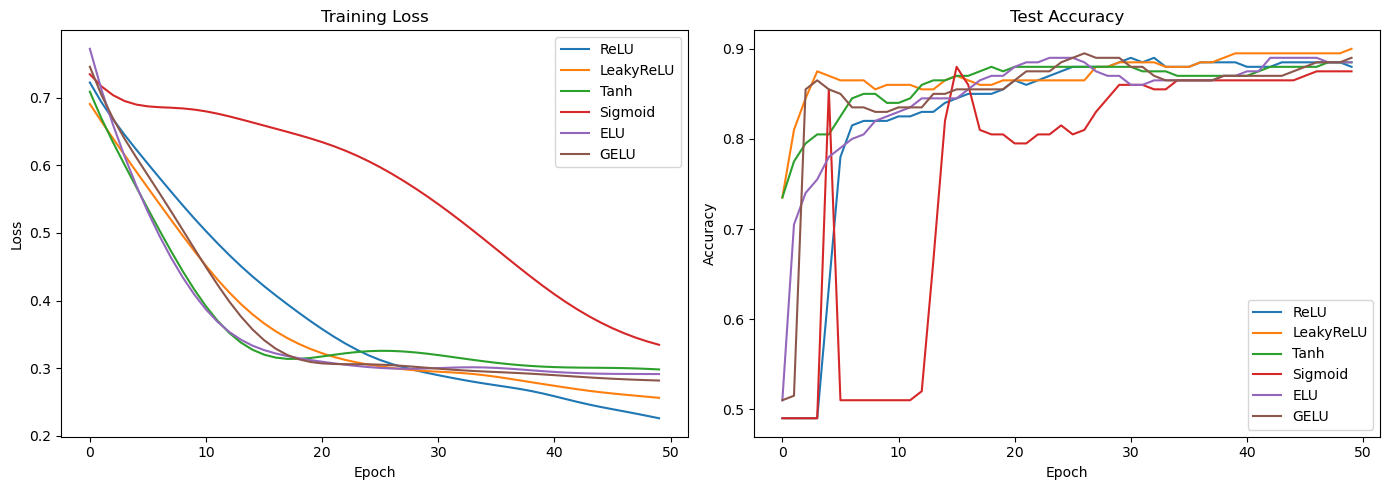

In [ ]:
# complete dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Simple MLP with configurable activation
class MLP(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            act_fn,
            nn.Linear(16, 16),
            act_fn,
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# 🏋️ Training loop
def train_model(act_name, act_fn, epochs=50):
    model = MLP(act_fn)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()
    train_losses, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        train_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Evaluation
        model.eval()
        with torch.no_grad():
            preds = (model(X_test) > 0.5).float()
            acc = (preds == y_test).float().mean().item()
            test_accs.append(acc)

    return train_losses, test_accs

# Activation functions to compare
activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.01),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "ELU": nn.ELU(),
    "GELU": nn.GELU()
}

# Run all activations
results = {}
for name, fn in activations.items():
    print(f"Training with {name}...")
    loss, acc = train_model(name, fn)
    results[name] = {"loss": loss, "acc": acc}

# Plot results
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
for name in results:
    plt.plot(results[name]["loss"], label=name)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
for name in results:
    plt.plot(results[name]["acc"], label=name)
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
 "" high variance and instability ""

# At some point, one or more layers receive a large gradient spike (possibly from unsaturated neurons).
# This leads to a sudden shift in the decision boundary.
# If the shift misaligns with the validation set → test accuracy drops sharply, then recovers.

In [ ]:
# dataset

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Prepare the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

from torchvision.datasets import MNIST

train_dataset = MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=False, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

# Define a simple feedforward neural network
class MLP(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.act1 = activation_fn
        self.fc2 = nn.Linear(256, 128)
        self.act2 = activation_fn
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

# Train and evaluate
def train_and_evaluate(activation_name, activation_fn, epochs=5):
    model = MLP(activation_fn).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    train_loss_log = []
    val_accuracy_log = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss_log.append(total_loss / len(train_loader))

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                correct += (preds.argmax(1) == yb).sum().item()
                total += yb.size(0)
        acc = correct / total
        val_accuracy_log.append(acc)

    return train_loss_log, val_accuracy_log

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Activation functions to compare
activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.01),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "ELU": nn.ELU(),
    "GELU": nn.GELU()
}

# Train models with each activation
results = {}
for name, fn in activations.items():
    print(f"\nTraining with {name}")
    loss_log, acc_log = train_and_evaluate(name, fn)
    results[name] = {"loss": loss_log, "acc": acc_log}

# Plotting
plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
for name in activations:
    plt.plot(results[name]["loss"], label=name)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
for name in activations:
    plt.plot(results[name]["acc"], label=name)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'torchvision'

In [ ]:
# Something to think!

In [ ]:
New school of thought : “What if we don't choose the best activation function... but let the network learn it?”

Activation Function as Learnable Component!


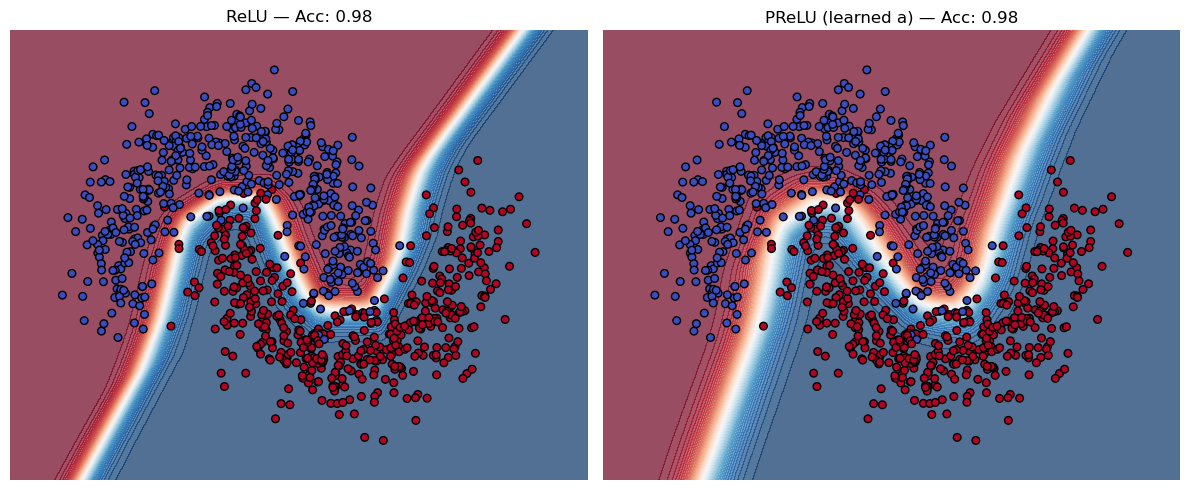

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define model with choice of activation
class MLP(nn.Module):
    def __init__(self, use_prelu=False):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.act1 = nn.PReLU() if use_prelu else nn.ReLU()
        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.PReLU() if use_prelu else nn.ReLU()
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.sigmoid(self.fc3(x))

# Train and return model + accuracy
def train_model(use_prelu=False, epochs=50):
    model = MLP(use_prelu)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        acc = ((model(X_test) > 0.5).float() == y_test).float().mean().item()
    return model, acc

# Train both models
relu_model, acc_relu = train_model(use_prelu=False)
prelu_model, acc_prelu = train_model(use_prelu=True)

# for name, param in prelu_model.named_parameters():
#     if "weight" not in name and "PReLU" in str(type(getattr(prelu_model, name.split(".")[0]))):
#         print(f"{name}: {param.item():.4f}")

# Plot decision boundary
def plot_decision_boundary(model, title):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 200),
                            torch.linspace(y_min, y_max, 200))
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
    with torch.no_grad():
        Z = model(grid).reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap="coolwarm", s=30)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(relu_model, f"ReLU — Acc: {acc_relu:.2f}")
plt.subplot(1, 2, 2)
plot_decision_boundary(prelu_model, f"PReLU (learned a) — Acc: {acc_prelu:.2f}")
plt.tight_layout()
plt.show()


In [ ]:
Could that outperform hand-designed ones?”

In [ ]:
That leads into PReLU, Swish, Mish, and even Neural Architecture Search (NAS) where the activation function is part of the search space!

# Batch Normalization?
“It normalizes the inputs to a layer, within a mini-batch, during training.”

In [ ]:
For each feature/channel:

𝑥^=𝑥−𝜇𝐵/𝜎𝐵2+𝜖
(normalize to mean 0, std 1)

Then:

𝑦=𝛾𝑥^+𝛽
(learnable scale and shift)

Where:𝜇𝐵,𝜎𝐵: mean and std dev across the batch
γ,β: learnable parameters (so the network can undo the normalization if needed)

In [ ]:
| Benefit                              | Why it helps                               |
| ------------------------------------ | ------------------------------------------ |
| **Faster training**                  | Gradients flow better; fewer epochs needed |
| **Reduces internal covariate shift** | Keeps activations on a stable scale        |
| **Stabilizes learning**              | Prevents exploding or vanishing gradients  |
| **Allows higher learning rates**     | Less risk of divergence                    |
| **Acts like regularization**         | Reduces overfitting even without dropout   |


# “Imagine each layer's input distribution keeps changing as the layers above update weights. That’s like trying to hit a moving target.
# BatchNorm freezes the input distribution, making learning stable.”

In [ ]:
# Comparing training with and without BatchNorm

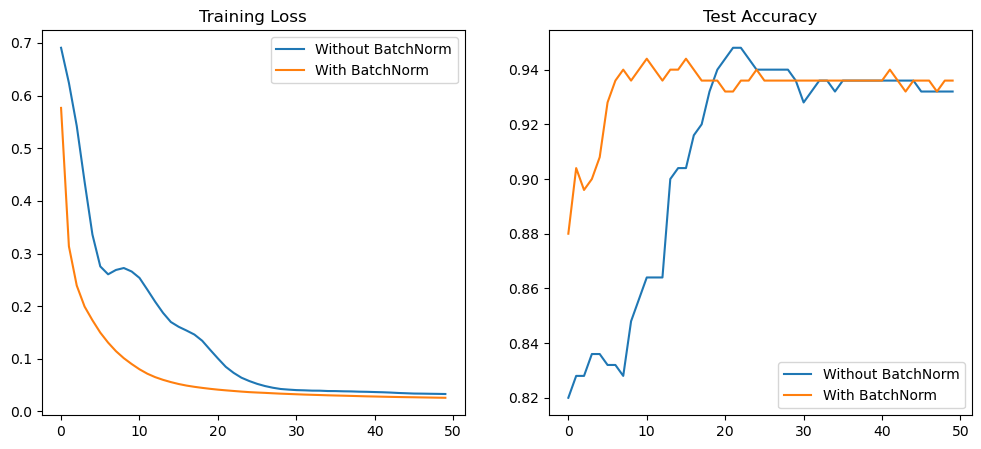

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define model
class MLP(nn.Module):
    def __init__(self, use_batchnorm=False):
        super().__init__()
        layers = []
        for _ in range(3):  # stack deep layers
            layers.append(nn.Linear(2 if len(layers)==0 else 64, 64))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(64))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(64, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Training loop
def train_model(use_batchnorm=False):
    model = MLP(use_batchnorm)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    losses, accs = [], []

    for _ in range(50):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        with torch.no_grad():
            acc = ((model(X_test) > 0.5).float() == y_test).float().mean().item()
            accs.append(acc)
    return losses, accs

# Run both
loss_plain, acc_plain = train_model(use_batchnorm=False)
loss_bn, acc_bn = train_model(use_batchnorm=True)

# Plot results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss_plain, label="Without BatchNorm")
plt.plot(loss_bn, label="With BatchNorm")
plt.title("Training Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(acc_plain, label="Without BatchNorm")
plt.plot(acc_bn, label="With BatchNorm")
plt.title("Test Accuracy")
plt.legend()
plt.show()


In [ ]:
Without BatchNorm: slower learning, unstable accuracy, sometimes exploding gradients
With BatchNorm: faster convergence, higher accuracy, smoother training

In [ ]:
# some visual examples

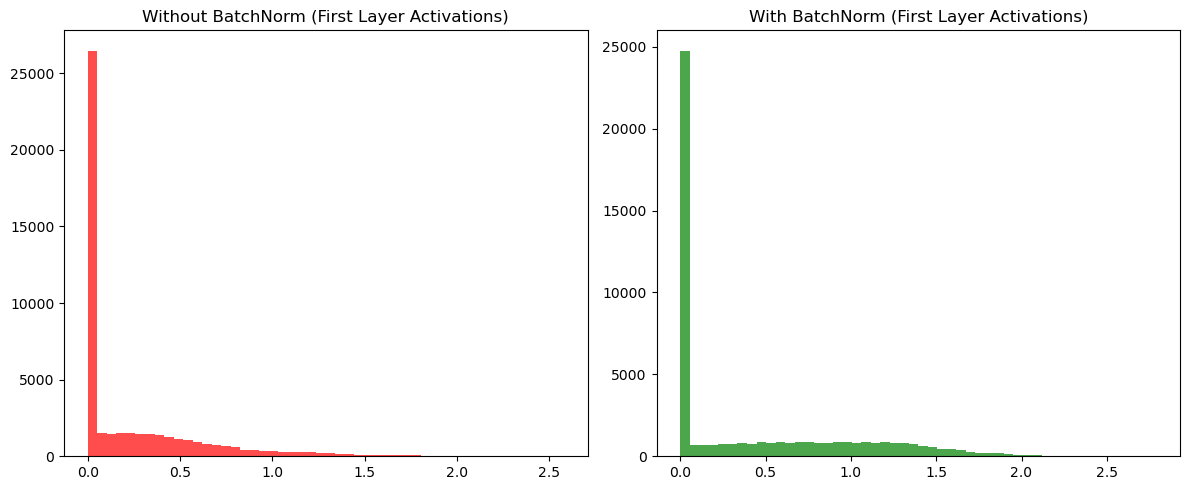

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.25)
X_train = torch.tensor(X_train, dtype=torch.float32)

# Helper to store activations
activations = {"with_bn": [], "without_bn": []}

# Hook to capture activations
def get_hook(name):
    def hook(module, input, output):
        activations[name].append(output.detach().numpy())
    return hook

# Define model with and without BatchNorm
class MLP(nn.Module):
    def __init__(self, use_batchnorm=False, hook_name=None):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.bn1 = nn.BatchNorm1d(64) if use_batchnorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 64)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(64, 1)

        # Register hook to capture activations from first ReLU
        if hook_name:
            self.relu1.register_forward_hook(get_hook(hook_name))

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)   # only applied if BN is used
        x = self.relu1(x) # hook here
        x = self.fc2(x)
        x = self.relu2(x)
        return torch.sigmoid(self.out(x))

# Run forward pass once to capture activations
with torch.no_grad():
    model_bn = MLP(use_batchnorm=True, hook_name="with_bn")
    model_no_bn = MLP(use_batchnorm=False, hook_name="without_bn")
    _ = model_bn(X_train)
    _ = model_no_bn(X_train)

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(activations["without_bn"][0].flatten(), bins=50, alpha=0.7, color="red")
plt.title("Without BatchNorm (First Layer Activations)")

plt.subplot(1, 2, 2)
plt.hist(activations["with_bn"][0].flatten(), bins=50, alpha=0.7, color="green")
plt.title("With BatchNorm (First Layer Activations)")

plt.tight_layout()
plt.show()


In [ ]:
Without BatchNorm: Activation values can be skewed, spread too wide, or stuck in non-informative zones

With BatchNorm: Activations are centered and nicely distributed → better gradient flow and learning

This is why BatchNorm is not just a hack — it rescales the internal activations to keep them in a good learning zone

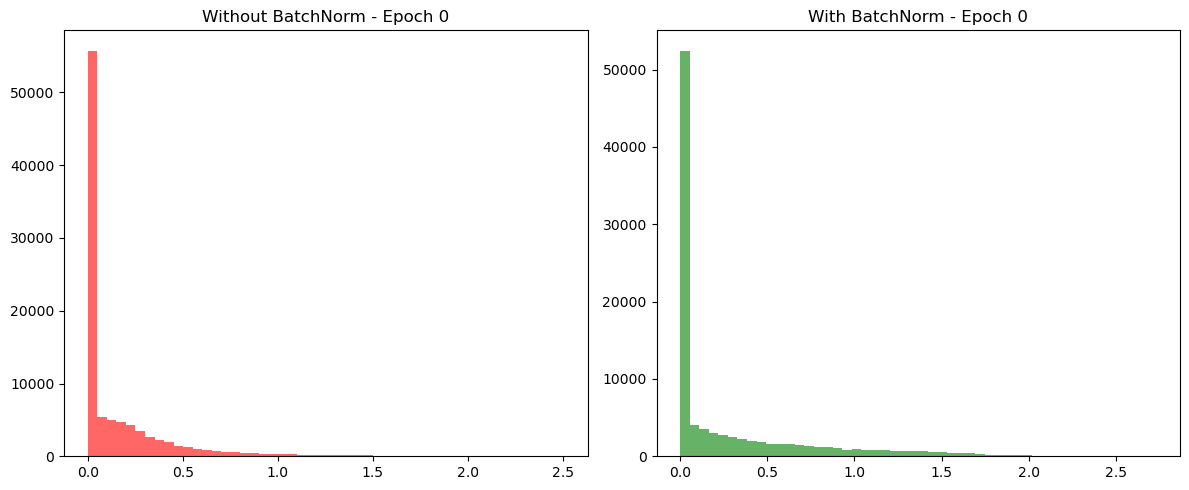

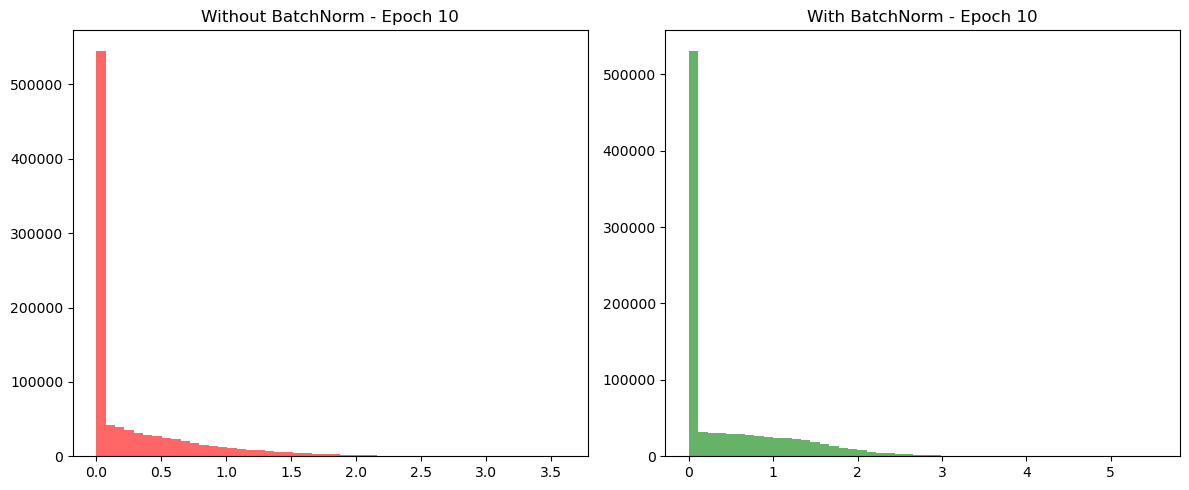

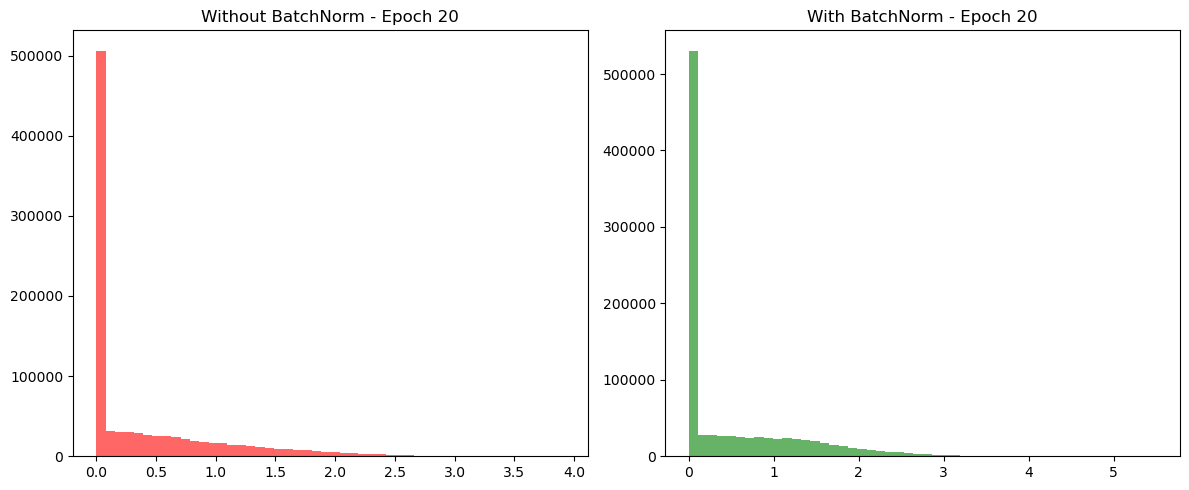

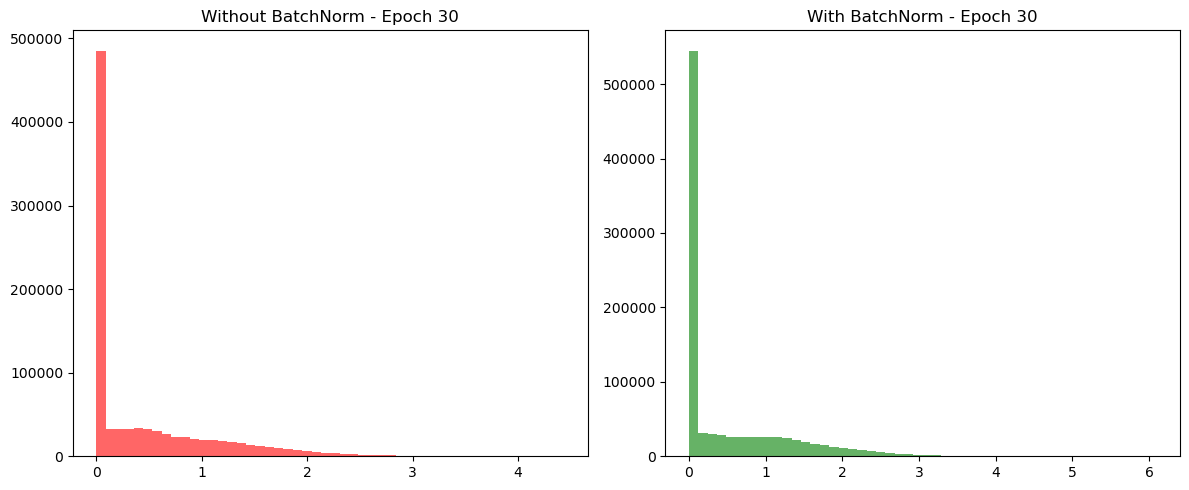

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.25)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

# Helper to store activations
def capture_hook(activations_list):
    def hook(module, input, output):
        activations_list.append(output.detach().cpu().numpy())
    return hook

# Define model
class MLP(nn.Module):
    def __init__(self, use_bn=False, activation_store=None):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.bn1 = nn.BatchNorm1d(64) if use_bn else nn.Identity()
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

        # Hook to capture first ReLU activation
        if activation_store is not None:
            self.relu.register_forward_hook(capture_hook(activation_store))

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        return self.sigmoid(self.out(x))

# Training
def train_model(use_bn, capture_epochs=[0, 10, 20, 30]):
    activation_snapshots = {}
    model = MLP(use_bn=use_bn, activation_store=[])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    for epoch in range(31):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch in capture_epochs:
            activation_snapshots[epoch] = model.relu.__dict__['_forward_hooks'][list(model.relu._forward_hooks)[0]].__closure__[0].cell_contents[:]
            model.relu._forward_hooks.clear()  # reset hook for next round
            model.relu.register_forward_hook(capture_hook([]))  # new container

    return activation_snapshots

# Run both
snap_no_bn = train_model(use_bn=False)
snap_bn = train_model(use_bn=True)

# Plot
for epoch in snap_no_bn:
    act_no_bn = np.concatenate(snap_no_bn[epoch], axis=0).flatten()
    act_bn = np.concatenate(snap_bn[epoch], axis=0).flatten()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(act_no_bn, bins=50, color='red', alpha=0.6)
    plt.title(f"Without BatchNorm - Epoch {epoch}")
    plt.subplot(1, 2, 2)
    plt.hist(act_bn, bins=50, color='green', alpha=0.6)
    plt.title(f"With BatchNorm - Epoch {epoch}")
    plt.tight_layout()
    plt.show()


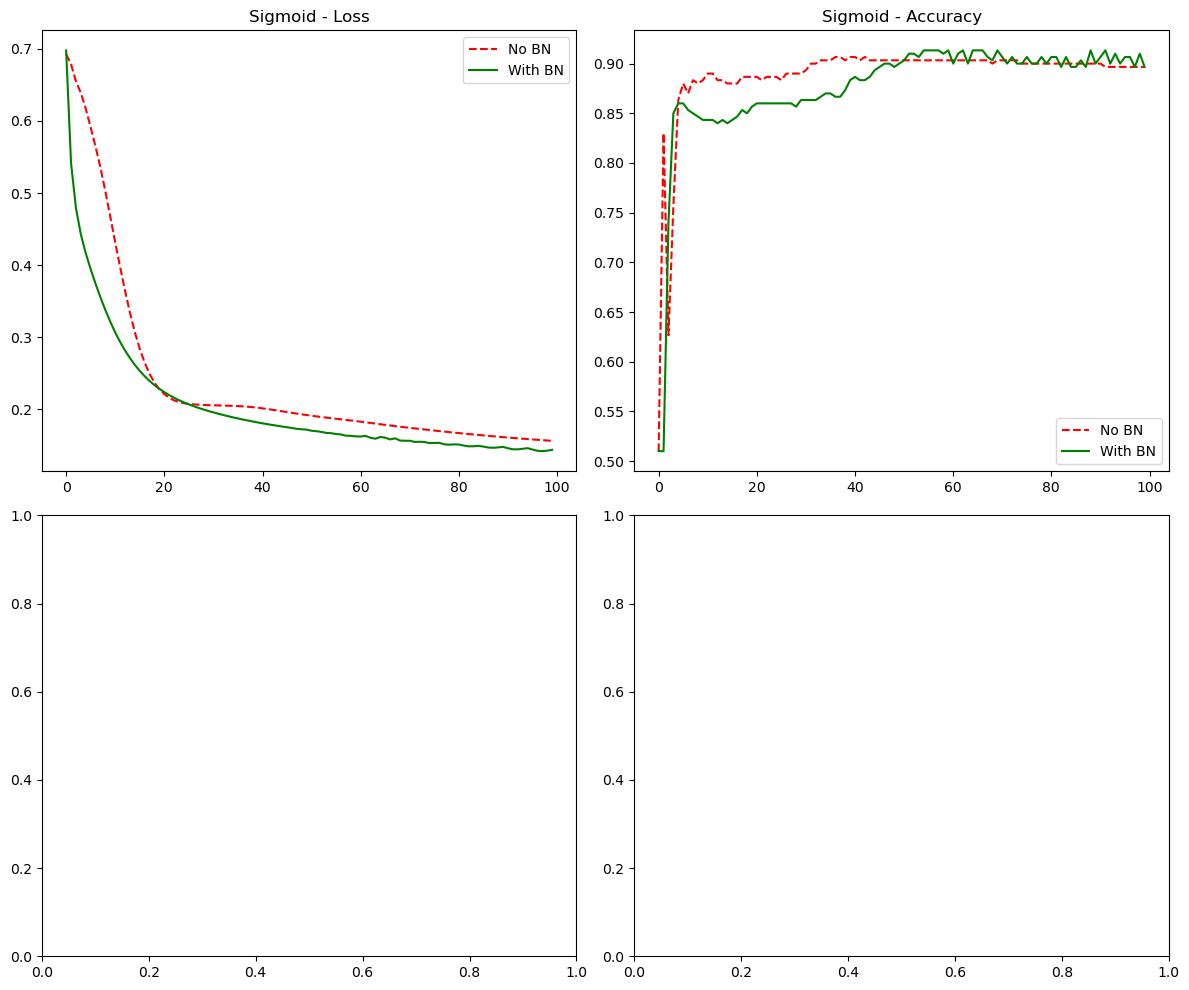

In [ ]:
# Sigmoid with batchnormalization

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Model
class MLP(nn.Module):
    def __init__(self, activation, use_bn=False):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.bn1 = nn.BatchNorm1d(64) if use_bn else nn.Identity()
        self.act1 = activation
        self.fc2 = nn.Linear(64, 64)
        self.bn2 = nn.BatchNorm1d(64) if use_bn else nn.Identity()
        self.act2 = activation
        self.out = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.out(x)
        return self.sigmoid(x)
# Training
def train_model(activation_fn, use_bn):
    model = MLP(activation_fn, use_bn)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    loss_list = []
    acc_list = []

    for epoch in range(100):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Evaluate
        model.eval()
        with torch.no_grad():
            y_test_pred = model(X_test)
            acc = ((y_test_pred > 0.5).float() == y_test).float().mean().item()
        loss_list.append(loss.item())
        acc_list.append(acc)

    return loss_list, acc_list

# Run tests
results = {}
for name, fn in [("Sigmoid", nn.Sigmoid())]:
    results[name] = {
        "no_bn": train_model(fn, use_bn=False),
        "with_bn": train_model(fn, use_bn=True)
    }

# Plot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, name in enumerate(results):
    loss_no_bn, acc_no_bn = results[name]["no_bn"]
    loss_bn, acc_bn = results[name]["with_bn"]

    axs[i, 0].plot(loss_no_bn, label="No BN", color="red", linestyle="--")
    axs[i, 0].plot(loss_bn, label="With BN", color="green")
    axs[i, 0].set_title(f"{name} - Loss")
    axs[i, 0].legend()

    axs[i, 1].plot(acc_no_bn, label="No BN", color="red", linestyle="--")
    axs[i, 1].plot(acc_bn, label="With BN", color="green")
    axs[i, 1].set_title(f"{name} - Accuracy")
    axs[i, 1].legend()

plt.tight_layout()
plt.show()


"Not all activations need BatchNorm, but some activations — like Sigmoid — perform poorly without it.
BatchNorm ensures activations stay in their ideal operating range and keeps gradients healthy."

# modern activations like GELU, Swish, or Mish, BatchNorm is often already baked into pretrained models.

In [ ]:
# just showing these activation functions

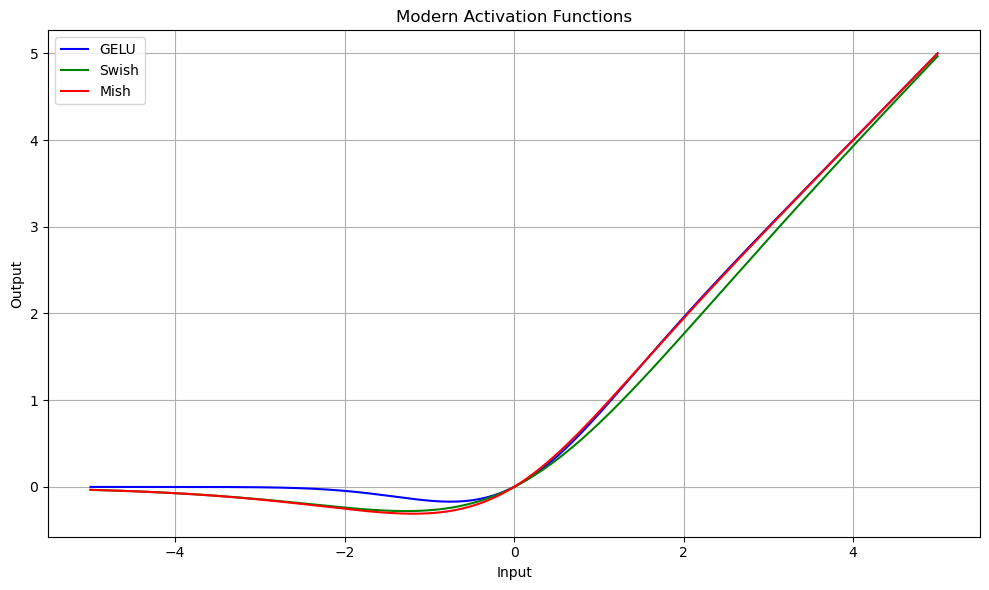

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Input range
x = torch.linspace(-5, 5, steps=500)

# Define activation functions
gelu = nn.GELU()
swish = lambda x: x * torch.sigmoid(x)
mish = lambda x: x * torch.tanh(nn.functional.softplus(x))

# Compute activations
y_gelu = gelu(x)
y_swish = swish(x)
y_mish = mish(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x.numpy(), y_gelu.numpy(), label="GELU", color='blue')
plt.plot(x.numpy(), y_swish.numpy(), label="Swish", color='green')
plt.plot(x.numpy(), y_mish.numpy(), label="Mish", color='red')
plt.title("Modern Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
| Function  | Smooth? | Range    | Notes                             |
| --------- | ------- | -------- | --------------------------------- |
| **GELU**  | Yes     | All real | Used in Transformers (e.g., BERT) |
| **Swish** | Yes     | All real | Better than ReLU for deeper nets  |
| **Mish**  | Yes     | All real | Self-regularizing, smooth variant |


Training with GELU activation...
Training with Swish activation...
Training with Mish activation...


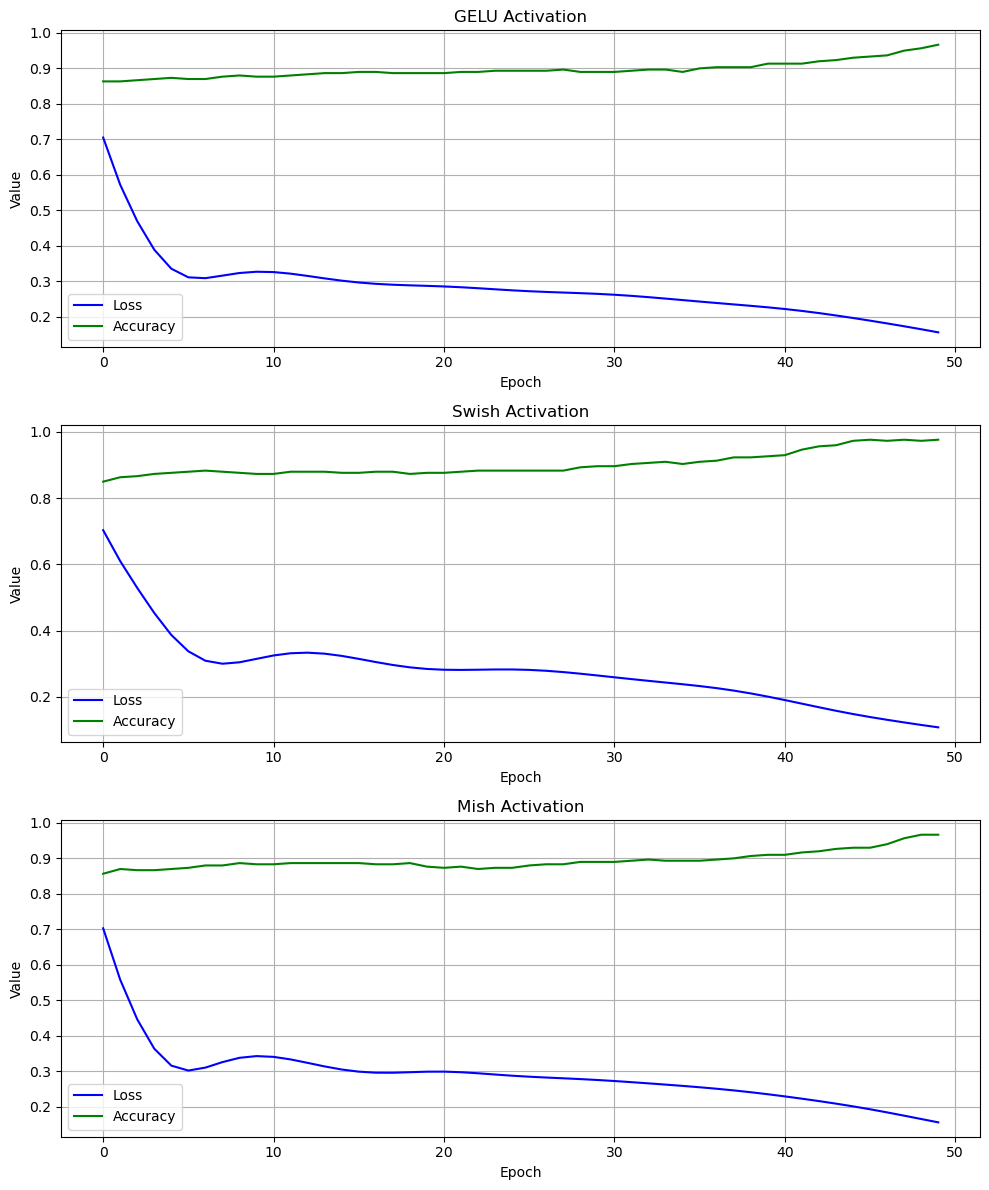

In [ ]:
# jsut an example... we will touch this while we cover CNNs
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create synthetic classification dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Define activations
gelu = nn.GELU()
swish = lambda x: x * torch.sigmoid(x)
mish = lambda x: x * torch.tanh(nn.functional.softplus(x))

# Define MLP class
class MLP(nn.Module):
    def __init__(self, activation_name):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)
        self.activation_name = activation_name

    def activation(self, x):
        if self.activation_name == "GELU":
            return gelu(x)
        elif self.activation_name == "Swish":
            return swish(x)
        elif self.activation_name == "Mish":
            return mish(x)
        else:
            return x

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.out(x)
        return torch.sigmoid(x)

# Train and evaluate function
def train_model(activation_name):
    model = MLP(activation_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    loss_list = []
    acc_list = []

    for epoch in range(50):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_pred = model(X_test)
            acc = ((y_test_pred > 0.5).float() == y_test).float().mean().item()
        loss_list.append(loss.item())
        acc_list.append(acc)

    return loss_list, acc_list

# Run for each activation
results = {}
for name in ["GELU", "Swish", "Mish"]:
    print(f"Training with {name} activation...")
    results[name] = train_model(name)

# Plot results
fig, axs = plt.subplots(3, 1, figsize=(10, 12))
for i, name in enumerate(results):
    losses, accs = results[name]
    axs[i].plot(losses, label="Loss", color='blue')
    axs[i].plot(accs, label="Accuracy", color='green')
    axs[i].set_title(f"{name} Activation")
    axs[i].set_xlabel("Epoch")
    axs[i].set_ylabel("Value")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()
